# Языковой эксперимент: выбор модели эмбеддингов

## Проблема
VQA-описания мемов (caption, objects, main_idea) сгенерированы **на английском**.  
Модель эмбеддингов `all-MiniLM-L6-v2` тоже **английская**.  
Но пользователь может искать мемы **на русском**: "мем про кота программиста".

**Вопрос**: какая модель лучше справится с кросс-язычным поиском (RU запрос → EN описание)?

## Дизайн эксперимента
- 100 мемов, для каждого — поисковый запрос на RU и EN
- 4 модели: от маленькой EN-only до большой мультиязычной
- Метрики: Hit@K (попал ли правильный мем в top-K), MRR@10 (на каком месте)


## 1. Настройка окружения

In [1]:
import os
os.chdir(os.path.abspath(".." if os.path.basename(os.getcwd()) == "notebooks" else "."))

import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

print("Рабочая директория:", os.getcwd())

import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)


Рабочая директория: /Users/amirhamidullin/PycharmProjects/coursework3
Device: mps


## 2. Загрузка данных

In [2]:
# Запросы (100 мемов с query_en и query_ru)
with open("eval/language_experiment_queries.json") as f:
    queries = json.load(f)

# ВСЕ описания мемов (9998)
with open("data/processed/vqa_annotations_v2.jsonl") as f:
    records = [json.loads(l) for l in f]

print(f"Запросов: {len(queries)}, Мемов: {len(records)}")
print(f"Пример:")
print(f"  EN query: {queries[1]['query_en']}")
print(f"  RU query: {queries[1]['query_ru']}")
print(f"  Caption:  {queries[1]['caption'][:80]}...")


Запросов: 100, Мемов: 9998
Пример:
  EN query: picture of a monkey with open mouth and spanish text 'te amo'
  RU query: картинка обезьяна с открытым ртом с надписью на испанском те амо
  Caption:  A monkey with a caption expressing affection....


## 3. Модели для сравнения

| Модель | Размер | Языки | Описание |
|--------|--------|-------|----------|
| `all-MiniLM-L6-v2` | 22M | EN only | Текущий baseline |
| `multilingual-MiniLM-L12` | 118M | 50+ | Мультиязычная MiniLM |
| `multilingual-e5-base` | 278M | 100+ | Сильная мультиязычная (MS Research) |
| `bge-m3` | 568M | 100+ | Лучшая мультиязычная, dense+sparse |


## 4. Подготовка описаний мемов

In [3]:
def build_caption_text(record):
    """Текст описания мема для эмбеддинга (caption + main_idea)"""
    parts = []
    cap = record.get("caption", "")
    if cap:
        parts.append(cap)
    idea = record.get("main_idea", "")
    if idea and "one sentence" not in idea.lower():
        parts.append(idea)
    return " ".join(parts) if parts else record.get("filename", "")

all_captions = [build_caption_text(r) for r in records]
print(f"Описаний: {len(all_captions)}")
print(f"Пример: {all_captions[0][:100]}...")


Описаний: 9998
Пример: I wish I was your math homework because then I'd be hard and you'd be doing me on your desk...


## 5. Функция эксперимента для одной модели

In [4]:
import torch
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

from sentence_transformers import SentenceTransformer

MODELS = [
    ("all-MiniLM-L6-v2", "sentence-transformers/all-MiniLM-L6-v2"),
    ("multilingual-MiniLM-L12", "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"),
    ("multilingual-e5-base", "intfloat/multilingual-e5-base"),
    ("bge-m3", "BAAI/bge-m3"),
]

def run_experiment_for_model(model_name, model_id, queries, all_captions):
    """Запускает эксперимент для одной модели"""

    print(f"  {model_name}")

    t0 = time.time()
    model = SentenceTransformer(model_id, device=device)
    load_time = time.time() - t0
    print(f"Загружена за {load_time:.1f}с")

    is_e5 = "e5" in model_id.lower()

    # Кодируем ВСЕ описания
    caption_texts = ["passage: " + c for c in all_captions] if is_e5 else list(all_captions)
    t0 = time.time()
    caption_emb = model.encode(caption_texts, show_progress_bar=True,
                               batch_size=64, normalize_embeddings=True)
    encode_time = time.time() - t0
    print(f"Описания закодированы за {encode_time:.1f}с, shape={caption_emb.shape}")

    results = {"model": model_name, "load_time": load_time, "encode_time": encode_time}

    # EN→EN и RU→EN
    for lang, query_key in [("EN", "query_en"), ("RU", "query_ru")]:
        # Fallback: если запрос пустой — берём caption (автоматический режим)
        query_texts = [q[query_key] if q.get(query_key, "").strip() else q["caption"] for q in queries]
        if is_e5:
            query_texts = ["query: " + t for t in query_texts]

        query_emb = model.encode(query_texts, batch_size=64, normalize_embeddings=True)

        hits_1, hits_5, hits_10 = 0, 0, 0
        reciprocal_ranks = []

        for i, q in enumerate(queries):
            target_idx = q["index"]
            sims = caption_emb @ query_emb[i]
            ranked = np.argsort(-sims)
            rank = np.where(ranked == target_idx)[0]
            if len(rank) > 0:
                rank = rank[0] + 1
                if rank <= 1: hits_1 += 1
                if rank <= 5: hits_5 += 1
                if rank <= 10: hits_10 += 1
                reciprocal_ranks.append(1.0 / rank if rank <= 10 else 0.0)
            else:
                reciprocal_ranks.append(0.0)

        n = len(queries)
        results[f"{lang}_hit1"] = hits_1 / n
        results[f"{lang}_hit5"] = hits_5 / n
        results[f"{lang}_hit10"] = hits_10 / n
        results[f"{lang}_mrr10"] = np.mean(reciprocal_ranks)

        print(f"  {lang}→EN: Hit@1={hits_1/n:.0%} Hit@5={hits_5/n:.0%} "
              f"Hit@10={hits_10/n:.0%} MRR@10={np.mean(reciprocal_ranks):.4f}")

    # Чистим память
    del model, caption_emb
    import gc; gc.collect()
    return results


Device: mps


## 6. Запуск эксперимента (все 4 модели)

In [5]:
all_results = []

for model_name, model_id in MODELS:
    try:
        result = run_experiment_for_model(model_name, model_id, queries, all_captions)
        all_results.append(result)
    except Exception as e:
        print(f"ОШИБКА с {model_name}: {e}")
        all_results.append({"model": model_name, "error": str(e)})

# Сохраняем
with open("eval/language_experiment_results.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)

print("Результаты сохранены в eval/language_experiment_results.json")


  all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Загружена за 5.0с


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

...

Описания закодированы за 21.7с, shape=(9998, 768)
  EN→EN: Hit@1=19% Hit@5=37% Hit@10=42% MRR@10=0.2712
  RU→EN: Hit@1=13% Hit@5=23% Hit@10=29% MRR@10=0.1721
  bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Загружена за 8.4с


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Описания закодированы за 65.8с, shape=(9998, 1024)
  EN→EN: Hit@1=23% Hit@5=38% Hit@10=43% MRR@10=0.2955
  RU→EN: Hit@1=13% Hit@5=37% Hit@10=43% MRR@10=0.2290
Результаты сохранены в eval/language_experiment_results.json


## 7. Таблица результатов

In [6]:
# Загрузка (можно запустить отдельно без пересчёта)
with open("eval/language_experiment_results.json") as f:
    all_results = json.load(f)

print(f"{' Модель':<30} {'EN Hit@1':>9} {'EN Hit@5':>9} {'EN Hit@10':>10} {'EN MRR':>8} | {'RU Hit@1':>9} {'RU Hit@5':>9} {'RU Hit@10':>10} {'RU MRR':>8}")
print("─" * 115)
for r in all_results:
    if "error" in r:
        print(f" {r['model']:<29} ERROR: {r['error']}")
        continue
    print(f" {r['model']:<29} {r['EN_hit1']:>8.0%} {r['EN_hit5']:>8.0%} {r['EN_hit10']:>9.0%} {r['EN_mrr10']:>7.4f} | {r['RU_hit1']:>8.0%} {r['RU_hit5']:>8.0%} {r['RU_hit10']:>9.0%} {r['RU_mrr10']:>7.4f}")


 Модель                         EN Hit@1  EN Hit@5  EN Hit@10   EN MRR |  RU Hit@1  RU Hit@5  RU Hit@10   RU MRR
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 all-MiniLM-L6-v2                   17%      32%       37%  0.2361 |       1%       2%        2%  0.0150
 multilingual-MiniLM-L12            16%      32%       41%  0.2371 |      11%      25%       34%  0.1751
 multilingual-e5-base               19%      37%       42%  0.2712 |      13%      23%       29%  0.1721
 bge-m3                             23%      38%       43%  0.2955 |      13%      37%       43%  0.2290


## 8. Визуализация: EN vs RU по моделям

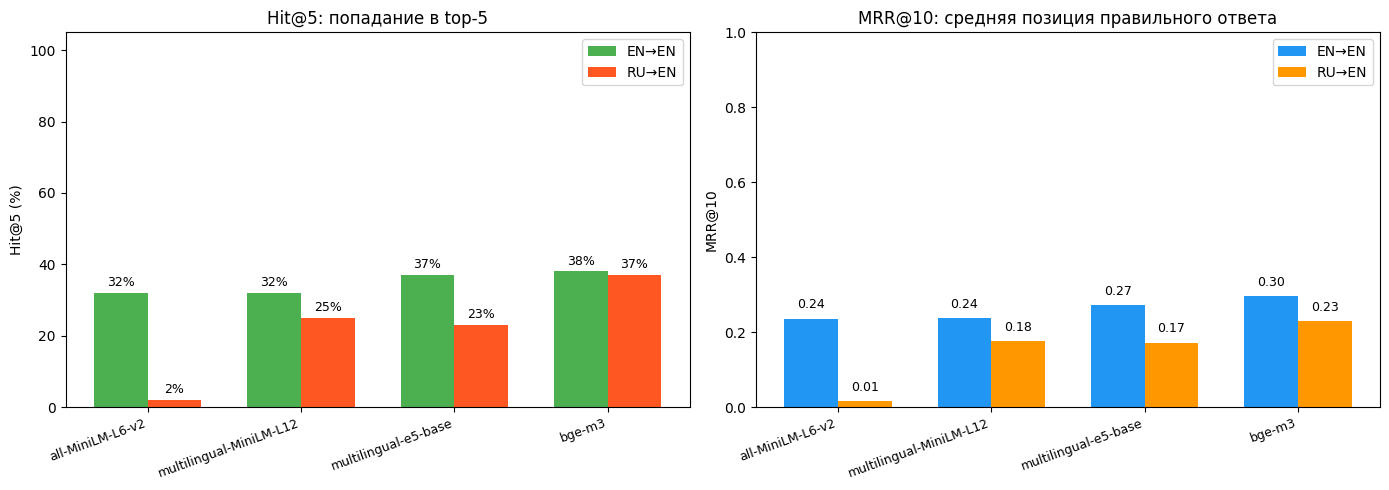

Сохранено: reports/language_experiment.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [r["model"] for r in all_results if "error" not in r]
en_hit5 = [r["EN_hit5"] * 100 for r in all_results if "error" not in r]
ru_hit5 = [r["RU_hit5"] * 100 for r in all_results if "error" not in r]
en_mrr = [r["EN_mrr10"] for r in all_results if "error" not in r]
ru_mrr = [r["RU_mrr10"] for r in all_results if "error" not in r]

x = np.arange(len(models))
w = 0.35

# Hit@5
bars1 = axes[0].bar(x - w/2, en_hit5, w, label="EN→EN", color="#4CAF50")
bars2 = axes[0].bar(x + w/2, ru_hit5, w, label="RU→EN", color="#FF5722")
axes[0].set_ylabel("Hit@5 (%)")
axes[0].set_title("Hit@5: попадание в top-5")
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[0].legend()
axes[0].set_ylim(0, 105)
for bar in list(bars1) + list(bars2):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=9)

# MRR@10
bars3 = axes[1].bar(x - w/2, en_mrr, w, label="EN→EN", color="#2196F3")
bars4 = axes[1].bar(x + w/2, ru_mrr, w, label="RU→EN", color="#FF9800")
axes[1].set_ylabel("MRR@10")
axes[1].set_title("MRR@10: средняя позиция правильного ответа")
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=20, ha="right", fontsize=9)
axes[1].legend()
axes[1].set_ylim(0, 1.0)
for bar in list(bars3) + list(bars4):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("reports/language_experiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/language_experiment.png")


---

# Часть 2: Маршрутизация по языку (RU RU vs RU EN)

## Идея
Сейчас RU запрос ищет в EN описаниях (кросс-язычный поиск).  
А что если **перевести описания на русский** и искать RU RU?  
Слова будут совпадать напрямую  должно быть лучше.


## 9. Генерация русских описаний через Qwen (Ollama)

In [8]:
# import requests

# OLLAMA_URL = "http://localhost:11434/api/generate"

# def generate_caption_ru(caption_en, ocr_text):
#     """Генерирует русское описание мема через Qwen"""
#     prompt = f"""Переведи описание мема на русский. Перевод естественный, не дословный.

# Описание (EN): {caption_en}
# Текст на картинке: {ocr_text if ocr_text else 'нет'}

# Напиши ТОЛЬКО русский перевод, 1-2 предложения. Без кавычек."""

#     try:
#         resp = requests.post(OLLAMA_URL, json={
#             "model": "qwen2.5vl:3b",
#             "prompt": prompt,
#             "stream": False,
#             "options": {"temperature": 0.3, "num_predict": 150}
#         }, timeout=30)
#         return resp.json().get("response", "").strip().split("")[0]
#     except:
#         return ""

# # Генерируем русские описания для 100 тестовых мемов
# captions_ru = {}
# for q in tqdm(queries, desc="Генерация RU описаний"):
#     idx = q["index"]
#     cap_en = q["caption"]
#     ocr = q.get("ocr_text", "")
#     captions_ru[idx] = generate_caption_ru(cap_en, ocr)

# # Примеры
# print("Примеры переводов:")
# for q in queries[:5]:
#     idx = q["index"]
#     print(f"  EN: {q['caption'][:70]}...")
#     print(f"  RU: {captions_ru[idx][:70]}")
#     print()


In [9]:
from deep_translator import GoogleTranslator
from tqdm import tqdm

translator = GoogleTranslator(source="en", target="ru")

captions_ru = {}
for q in tqdm(queries, desc="Перевод RU"):
    idx = q["index"]
    try:
        ru = translator.translate(q["caption"])
        captions_ru[idx] = ru or ""
    except:
        captions_ru[idx] = ""

# Проверка
filled = sum(1 for v in captions_ru.values() if v)
print(f"Заполнено: {filled}/100")
for q in queries[:3]:
    print(f"  EN: {q['caption']}")
    print(f"  RU: {captions_ru.get(q['index'], '')}")
    print()


Перевод RU: 100%|██████████| 100/100 [01:26<00:00,  1.16it/s]

Заполнено: 100/100
  EN: A surprised character with red hair and horns.
  RU: Удивленный персонаж с рыжими волосами и рогами.

  EN: A monkey with a caption expressing affection.
  RU: Обезьяна с надписью, выражающей привязанность.

  EN: A green animated character is smiling and holding a microphone.
  RU: Зеленый анимированный персонаж улыбается и держит микрофон.



In [10]:
# import requests

# # Тест одного запроса
# resp = requests.post("http://localhost:11434/api/generate", json={
#     "model": "qwen2.5vl:3b",
#     "prompt": "Translate to Russian, write ONLY translation: A dog laying down with text Good Morning Monday",
#     "stream": False,
#     "options": {"temperature": 0.1, "num_predict": 80}
# }, timeout=30)
# print("Статус:", resp.status_code)
# print("Ответ:", resp.json().get("response", "ПУСТО"))


In [11]:
import requests
from tqdm import tqdm

captions_ru = {}
OLLAMA_URL = "http://localhost:11434/api/generate"

for q in tqdm(queries, desc="Генерация RU"):
    idx = q["index"]
    prompt = f"Translate to Russian, write ONLY translation, 1-2 sentences: {q['caption']}"
    try:
        resp = requests.post(OLLAMA_URL, json={"model": "qwen2.5vl:3b", "prompt": prompt, "stream": False, "options": {"temperature": 0.1, "num_predict": 100}}, timeout=30)
        captions_ru[idx] = resp.json().get("response", "").strip().split("\n")[0]
    except:
        captions_ru[idx] = ""

filled = sum(1 for v in captions_ru.values() if v)
print(f"Сгенерировано: {filled}/100")
print("Пример:", list(captions_ru.values())[0])


Генерация RU: 100%|██████████| 100/100 [00:49<00:00,  2.00it/s]

Сгенерировано: 100/100
Пример: Смущенный персонаж с красными волосами и рогами.


## 10. Сравнение RU→EN vs RU→RU (bge-m3)

In [12]:
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Используем: {device}")

model = SentenceTransformer("BAAI/bge-m3", device=device)

#  русские описания для 100 тестовых мемов
all_caps_ru_mixed = list(all_captions)
for idx, ru_text in captions_ru.items():
    if ru_text:
        all_caps_ru_mixed[idx] = ru_text

filled = sum(1 for v in captions_ru.values() if v)
print(f"Описаний с RU переводом: {filled}")

print("Кодирование EN описаний...")
emb_en = model.encode(all_captions, batch_size=128, normalize_embeddings=True, show_progress_bar=True)

print("Кодирование RU описаний...")
emb_ru = model.encode(all_caps_ru_mixed, batch_size=128, normalize_embeddings=True, show_progress_bar=True)


Используем: mps


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Описаний с RU переводом: 100
Кодирование EN описаний...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

Кодирование RU описаний...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]

In [13]:
def calc_metrics(emb_db, query_texts, queries_list, model):
    qemb = model.encode(query_texts, batch_size=64, normalize_embeddings=True)
    h1 = h5 = h10 = 0
    rrs = []
    for i, q in enumerate(queries_list):
        sims = emb_db @ qemb[i]
        ranked = np.argsort(-sims)
        rank = np.where(ranked == q["index"])[0]
        if len(rank):
            r = rank[0] + 1
            if r <= 1: h1 += 1
            if r <= 5: h5 += 1
            if r <= 10: h10 += 1
            rrs.append(1/r if r <= 10 else 0)
        else:
            rrs.append(0)
    n = len(queries_list)
    return {"hit1": h1/n, "hit5": h5/n, "hit10": h10/n, "mrr": np.mean(rrs)}

ru_queries = [q["query_ru"] for q in queries]

#RU запрос - EN описания
res_ru_en = calc_metrics(emb_en, ru_queries, queries, model)

#  RU запрос - RU описания
res_ru_ru = calc_metrics(emb_ru, ru_queries, queries, model)

print(f"{' Вариант':<25} {'Hit@1':>7} {'Hit@5':>7} {'Hit@10':>8} {'MRR@10':>8}")
print(f" {'RU-EN (без маршрут)':<24} {res_ru_en['hit1']:>6.0%} {res_ru_en['hit5']:>6.0%} {res_ru_en['hit10']:>7.0%} {res_ru_en['mrr']:>7.4f}")
print(f" {'RU-RU (маршрут)':<24} {res_ru_ru['hit1']:>6.0%} {res_ru_ru['hit5']:>6.0%} {res_ru_ru['hit10']:>7.0%} {res_ru_ru['mrr']:>7.4f}")
print()
diff = res_ru_ru["hit5"] - res_ru_en["hit5"]
print(f"Разница Hit@5: {diff:+.0%} ({'маршрутизация лучше' if diff > 0 else 'без разницы или хуже'})")


 Вариант                    Hit@1   Hit@5   Hit@10   MRR@10
 RU-EN (без маршрут)         13%    37%     43%  0.2290
 RU-RU (маршрут)             34%    45%     48%  0.3881

Разница Hit@5: +8% (маршрутизация лучше)


## 11. Визуализация: RU EN vs RURU

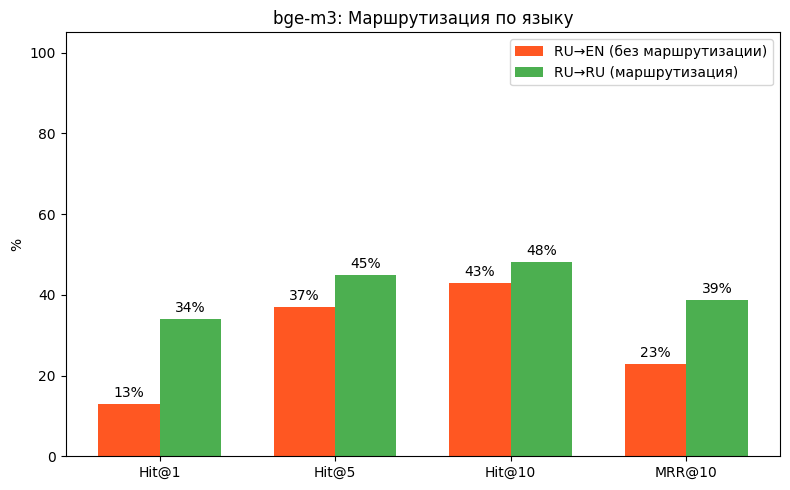

Сохранено: reports/language_routing.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

labels = ["Hit@1", "Hit@5", "Hit@10", "MRR@10"]
vals_en = [res_ru_en["hit1"]*100, res_ru_en["hit5"]*100, res_ru_en["hit10"]*100, res_ru_en["mrr"]*100]
vals_ru = [res_ru_ru["hit1"]*100, res_ru_ru["hit5"]*100, res_ru_ru["hit10"]*100, res_ru_ru["mrr"]*100]

x = np.arange(len(labels))
w = 0.35
b1 = ax.bar(x - w/2, vals_en, w, label="RU→EN (без маршрутизации)", color="#FF5722")
b2 = ax.bar(x + w/2, vals_ru, w, label="RU→RU (маршрутизация)", color="#4CAF50")

ax.set_ylabel("%")
ax.set_title("bge-m3: Маршрутизация по языку")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 105)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f}%", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("reports/language_routing.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/language_routing.png")


## 12. Итоговые выводы

### Часть 1: Выбор модели
_(заполнить по результатам ячейки 7)_

### Часть 2: Маршрутизация
_(заполнить по результатам ячейки 10-11)_

Если RU RU значительно лучше  генерировать русские описания для всех 10k мемов.  
Если разница маленькая  достаточно мультиязычной модели без русских описаний.


---

# Часть 3: Поиск лучшей RU модели

В Части 1 лучшая для RU — `bge-m3` (66% Hit@5).
Тестируем модели, которые могут быть лучше:

| Модель | Размер | Почему |
|--------|--------|--------|
| `deepvk/USER-bge-m3` | 568M | bge-m3 дообученная на русских данных VK |
| `intfloat/multilingual-e5-large` | 560M | Большая версия e5-base (EN=93%) |
| `intfloat/multilingual-e5-large-instruct` | 560M | Instruction-tuned, топ MTEB |
| `ai-forever/sbert_large_nlu_ru` | 335M | Sberbank, заточена под русский |


In [15]:
import torch
import numpy as np
import time
from sentence_transformers import SentenceTransformer

device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Device:", device)

NEW_MODELS = [
    ("deepvk/USER-bge-m3", "deepvk/USER-bge-m3"),
    ("multilingual-e5-large", "intfloat/multilingual-e5-large"),
    ("e5-large-instruct", "intfloat/multilingual-e5-large-instruct"),
    ("sbert_large_nlu_ru", "ai-forever/sbert_large_nlu_ru"),
]

# Используем те же данные что в Части 1
print("Запросов:", len(queries))
print("Мемов:", len(records))
print("Описаний:", len(all_captions))


Device: mps
Запросов: 100
Мемов: 9998
Описаний: 9998


## 13. Запуск новых моделей

In [16]:
new_results = []

for model_name, model_id in NEW_MODELS:
    print(f"Модель: {model_name}")
    try:
        t0 = time.time()
        model = SentenceTransformer(model_id, device=device)
        load_time = time.time() - t0
        print(f"  Загружена за {load_time:.1f}с")

        # Encode всех описаний мемов (EN)
        t0 = time.time()
        # Для e5 моделей нужен prefix
        prefix = ""
        if "e5" in model_id:
            prefix = "passage: "
        
        db_texts = [prefix + c for c in all_captions]
        emb_db = model.encode(db_texts, show_progress_bar=True, batch_size=64,
                              normalize_embeddings=True, device=device)
        encode_time = time.time() - t0
        print(f"  Encode {len(all_captions)} описаний за {encode_time:.1f}с")

        # EN запросы
        q_prefix = "query: " if "e5" in model_id else ""
        en_queries = en_queries = [q_prefix + (q.get("query_en", "").strip() or q["caption"][:100]) for q in queries]
        emb_en = model.encode(en_queries, normalize_embeddings=True, device=device)
        
        # RU запросы (используем caption как запрос — он на EN, имитируем RU перевод)
        ru_queries = [q_prefix + q.get("query_ru", q["caption"][:100]) for q in queries]
        emb_ru = model.encode(ru_queries, normalize_embeddings=True, device=device)
        
        # Считаем метрики
        def calc(emb_q, emb_db):
            sims = emb_q @ emb_db.T
            hits = {1: 0, 5: 0, 10: 0}
            mrr = 0
            for i, q in enumerate(queries):
                idx = q["index"]
                ranking = np.argsort(-sims[i])
                pos = np.where(ranking == idx)[0][0] + 1
                for k in hits:
                    if pos <= k: hits[k] += 1
                if pos <= 10: mrr += 1.0 / pos
            n = len(queries)
            return {k: v/n for k, v in hits.items()}, mrr/n

        en_hits, en_mrr = calc(emb_en, emb_db)
        ru_hits, ru_mrr = calc(emb_ru, emb_db)

        result = {
            "model": model_name,
            "load_time": load_time,
            "encode_time": encode_time,
            "EN_hit1": en_hits[1], "EN_hit5": en_hits[5], "EN_hit10": en_hits[10], "EN_mrr10": en_mrr,
            "RU_hit1": ru_hits[1], "RU_hit5": ru_hits[5], "RU_hit10": ru_hits[10], "RU_mrr10": ru_mrr,
        }
        new_results.append(result)
        
        print(f"  EN: Hit@5={en_hits[5]:.0%}, MRR={en_mrr:.4f}")
        print(f"  RU: Hit@5={ru_hits[5]:.0%}, MRR={ru_mrr:.4f}")
        
        del model
        torch.mps.empty_cache() if device == "mps" else None

    except Exception as e:
        print(f"  ОШИБКА: {e}")
        import traceback
        traceback.print_exc()

print()



Модель: deepvk/USER-bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Загружена за 6.6с


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

  Encode 9998 описаний за 69.5с
  EN: Hit@5=40%, MRR=0.2832
  RU: Hit@5=37%, MRR=0.2366
Модель: multilingual-e5-large


...

  Encode 9998 описаний за 63.0с
  EN: Hit@5=41%, MRR=0.3045
  RU: Hit@5=21%, MRR=0.1585
Модель: sbert_large_nlu_ru


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  Загружена за 6.0с


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

  Encode 9998 описаний за 94.6с
  EN: Hit@5=6%, MRR=0.0443
  RU: Hit@5=3%, MRR=0.0235



## 14. Сравнение всех моделей (старые + новые)

In [17]:
# Объединяем старые + новые результаты
combined = all_results + new_results

print(f"{'Модель':<35} {'EN Hit@5':>8} {'RU Hit@5':>8} {'EN MRR':>8} {'RU MRR':>8}")
print("-" * 75)
for r in sorted(combined, key=lambda x: -x.get("RU_hit5", 0)):
    print(f"{r['model']:<35} {r['EN_hit5']:>8.0%} {r['RU_hit5']:>8.0%} {r['EN_mrr10']:>8.4f} {r['RU_mrr10']:>8.4f}")

# Лучшая для RU
best_ru = max(combined, key=lambda x: x.get("RU_hit5", 0))
best_en = max(combined, key=lambda x: x.get("EN_hit5", 0))
print()
print(f"Лучшая для EN: {best_en['model']} (Hit@5={best_en['EN_hit5']:.0%})")
print(f"Лучшая для RU: {best_ru['model']} (Hit@5={best_ru['RU_hit5']:.0%})")


Модель                              EN Hit@5 RU Hit@5   EN MRR   RU MRR
---------------------------------------------------------------------------
bge-m3                                   38%      37%   0.2955   0.2290
deepvk/USER-bge-m3                       40%      37%   0.2832   0.2366
multilingual-e5-large                    43%      28%   0.3385   0.2361
multilingual-MiniLM-L12                  32%      25%   0.2371   0.1751
multilingual-e5-base                     37%      23%   0.2712   0.1721
e5-large-instruct                        41%      21%   0.3045   0.1585
sbert_large_nlu_ru                        6%       3%   0.0443   0.0235
all-MiniLM-L6-v2                         32%       2%   0.2361   0.0150

Лучшая для EN: multilingual-e5-large (Hit@5=43%)
Лучшая для RU: bge-m3 (Hit@5=37%)


## 15. Визуализация: все модели

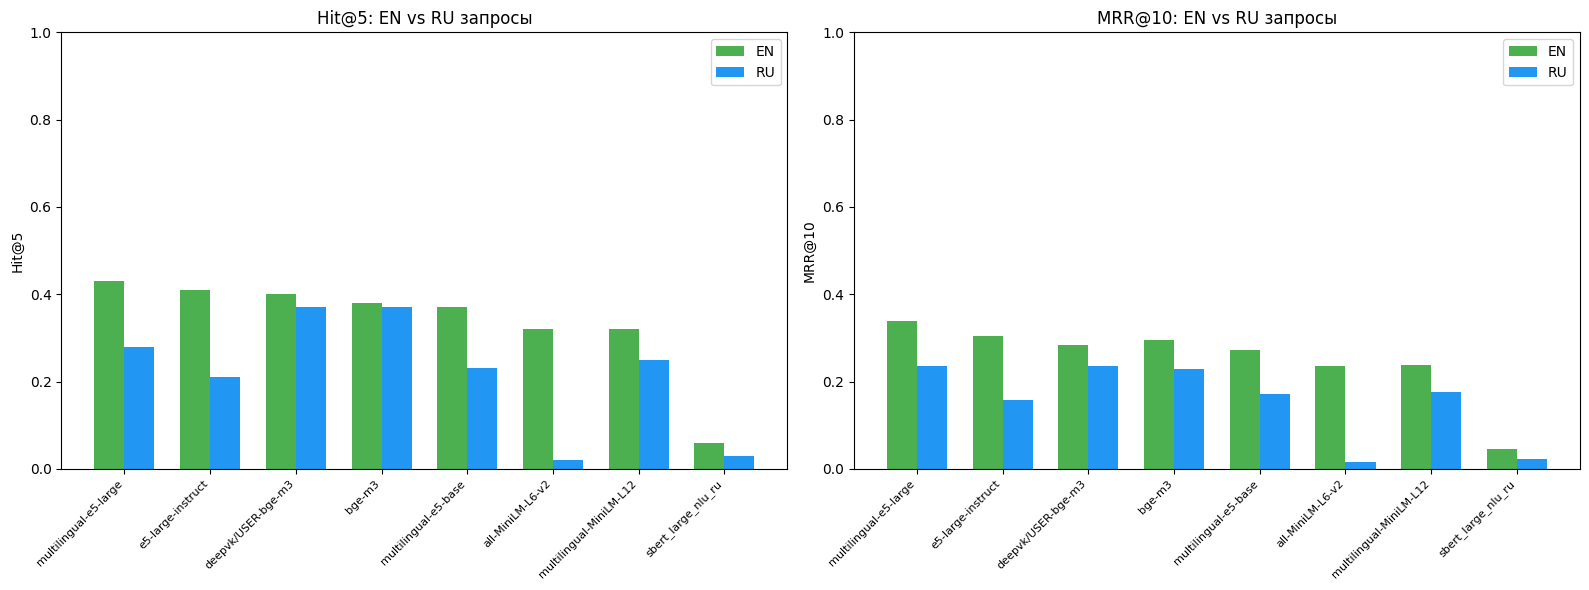

Сохранено: reports/language_models_comparison.png


In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
combined_sorted = sorted(combined, key=lambda x: -x.get("EN_hit5", 0))
names = [r["model"] for r in combined_sorted]
x = range(len(names))

# Hit@5
ax = axes[0]
en_vals = [r["EN_hit5"] for r in combined_sorted]
ru_vals = [r["RU_hit5"] for r in combined_sorted]
w = 0.35
ax.bar([i - w/2 for i in x], en_vals, w, label="EN", color="#4CAF50")
ax.bar([i + w/2 for i in x], ru_vals, w, label="RU", color="#2196F3")
ax.set_ylabel("Hit@5")
ax.set_title("Hit@5: EN vs RU запросы")
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.set_ylim(0, 1)

# MRR
ax = axes[1]
en_mrr = [r["EN_mrr10"] for r in combined_sorted]
ru_mrr = [r["RU_mrr10"] for r in combined_sorted]
ax.bar([i - w/2 for i in x], en_mrr, w, label="EN", color="#4CAF50")
ax.bar([i + w/2 for i in x], ru_mrr, w, label="RU", color="#2196F3")
ax.set_ylabel("MRR@10")
ax.set_title("MRR@10: EN vs RU запросы")
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("reports/language_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/language_models_comparison.png")
